In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

print("✅ Libraries imported!")

✅ Libraries imported!


In [12]:
from google.colab import files
import io

print("📂 Please upload your CSV file:")
uploaded = files.upload()

filename = list(uploaded.keys())[0]
print(f"\n✅ Loading: {filename}")

df = pd.read_csv(io.BytesIO(uploaded[filename]))

print(f"\n📊 Dataset loaded!")
print(f"Shape: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"\nColumns: {list(df.columns)}")

print("\n" + "="*60)
print("FIRST 5 ROWS (BEFORE CLEANING):")
print("="*60)
df.head()


📂 Please upload your CSV file:


Saving healthcare-dataset-stroke-data-selected-columns.csv to healthcare-dataset-stroke-data-selected-columns (2).csv

✅ Loading: healthcare-dataset-stroke-data-selected-columns (2).csv

📊 Dataset loaded!
Shape: 5110 rows, 10 columns

Columns: ['id', 'gender', 'age', 'hypertension', 'heart_disease', 'ever_married', 'work_type', 'Residence_type', 'avg_glucose_level', 'bmi']

FIRST 5 ROWS (BEFORE CLEANING):


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0


In [13]:
print("\n" + "="*60)
print("DATA QUALITY CHECK (BEFORE CLEANING)")
print("="*60)

print("\n1️⃣ MISSING VALUES:")
print(df.isnull().sum())

print("\n2️⃣ DATA TYPES:")
print(df.dtypes)

print("\n3️⃣ DUPLICATE ROWS:")
print(f"Duplicate rows: {df.duplicated().sum()}")

print("\n4️⃣ BASIC STATISTICS:")
df.describe()



DATA QUALITY CHECK (BEFORE CLEANING)

1️⃣ MISSING VALUES:
id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
dtype: int64

2️⃣ DATA TYPES:
id                     int64
gender                object
age                  float64
hypertension           int64
heart_disease          int64
ever_married          object
work_type             object
Residence_type        object
avg_glucose_level    float64
bmi                  float64
dtype: object

3️⃣ DUPLICATE ROWS:
Duplicate rows: 0

4️⃣ BASIC STATISTICS:


,id,age,hypertension,heart_disease,avg_glucose_level,bmi
count,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000,4909.000000
mean,36517.829354,43.226614,0.097456,0.054012,106.147677,28.893237
std,21161.721625,22.612647,0.296607,0.226063,45.283560,7.854067
min,67.000000,0.080000,0.000000,0.000000,55.120000,10.300000
25%,17741.250000,25.000000,0.000000,0.000000,77.245000,23.500000
50%,36932.000000,45.000000,0.000000,0.000000,91.885000,28.100000
75%,54682.000000,61.000000,0.000000,0.000000,114.090000,33.100000
max,72940.000000,82.000000,1.000000,1.000000,271.740000,97.600000


In [14]:
print("\n" + "="*60)
print("DATA CLEANING")
print("="*60)

df_clean = df.copy()

# Drop ID column
if 'id' in df_clean.columns:
    df_clean = df_clean.drop('id', axis=1)
    print("✅ Dropped 'id' column")

# Handle missing values in BMI
if 'bmi' in df_clean.columns:
    missing_bmi = df_clean['bmi'].isnull().sum()
    if missing_bmi > 0:
        bmi_median = df_clean['bmi'].median()
        df_clean['bmi'] = df_clean['bmi'].fillna(bmi_median)
        print(f"✅ BMI: filled {missing_bmi} missing values with median ({bmi_median:.1f})")

# Remove duplicates
dupes = df_clean.duplicated().sum()
if dupes > 0:
    df_clean = df_clean.drop_duplicates()
    print(f"✅ Removed {dupes} duplicate rows")

print("\n" + "="*60)
print("AFTER CLEANING - First 5 rows:")
print("="*60)
df_clean.head()

print("\n" + "="*60)
print("AFTER CLEANING - Missing Values:")
print("="*60)
print(df_clean.isnull().sum())
print(f"\n✅ Total missing values: {df_clean.isnull().sum().sum()}")


DATA CLEANING
✅ Dropped 'id' column
✅ BMI: filled 201 missing values with median (28.1)

AFTER CLEANING - First 5 rows:

AFTER CLEANING - Missing Values:
gender               0
age                  0
hypertension         0
heart_disease        0
ever_married         0
work_type            0
Residence_type       0
avg_glucose_level    0
bmi                  0
dtype: int64

✅ Total missing values: 0


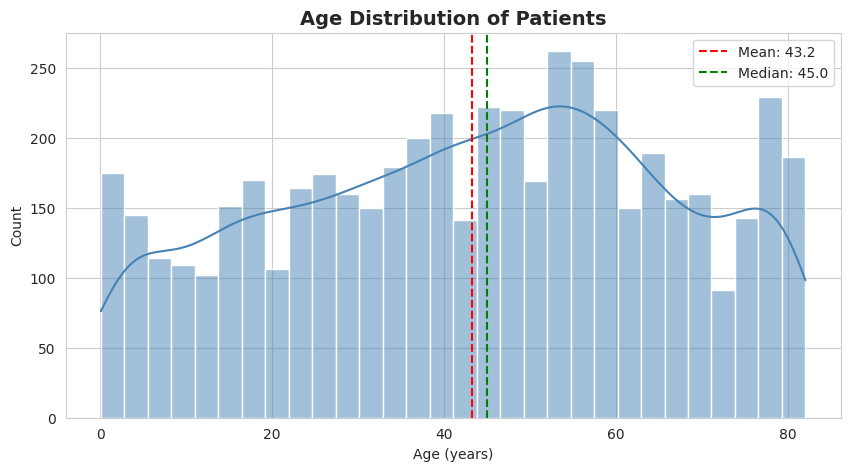


📊 INSIGHT:
   • Average age: 43.2 years
   • Median age: 45.0 years
   • Age range: 0 to 82 years


In [16]:
#Plot 1 - Age Distribution
plt.figure(figsize=(10, 5))
sns.histplot(df_clean['age'], bins=30, kde=True, color='steelblue')
plt.title('Age Distribution of Patients', fontsize=14, fontweight='bold')
plt.xlabel('Age (years)')
plt.ylabel('Count')
plt.axvline(df_clean['age'].mean(), color='red', linestyle='--',
            label=f'Mean: {df_clean["age"].mean():.1f}')
plt.axvline(df_clean['age'].median(), color='green', linestyle='--',
            label=f'Median: {df_clean["age"].median():.1f}')
plt.legend()
plt.show()

print(f"\n📊 INSIGHT:")
print(f"   • Average age: {df_clean['age'].mean():.1f} years")
print(f"   • Median age: {df_clean['age'].median():.1f} years")
print(f"   • Age range: {df_clean['age'].min():.0f} to {df_clean['age'].max():.0f} years")

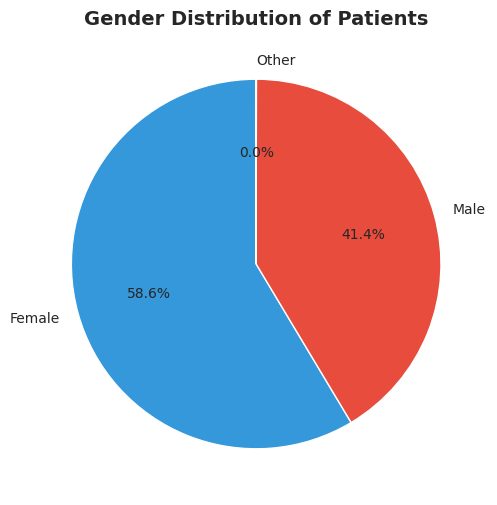


📊 INSIGHT:
   • Female: 2994 (58.6%)
   • Male: 2115 (41.4%)
   • Other: 1 (0.0%)


In [17]:
# Plot 2 - Gender Distribution
gender_counts = df_clean['gender'].value_counts()

plt.figure(figsize=(8, 6))
colors = ['#3498db', '#e74c3c']
plt.pie(gender_counts.values, labels=gender_counts.index,
        autopct='%1.1f%%', colors=colors, startangle=90)
plt.title('Gender Distribution of Patients', fontsize=14, fontweight='bold')
plt.show()

print(f"\n📊 INSIGHT:")
for gender, count in gender_counts.items():
    print(f"   • {gender}: {count} ({count/len(df_clean)*100:.1f}%)")


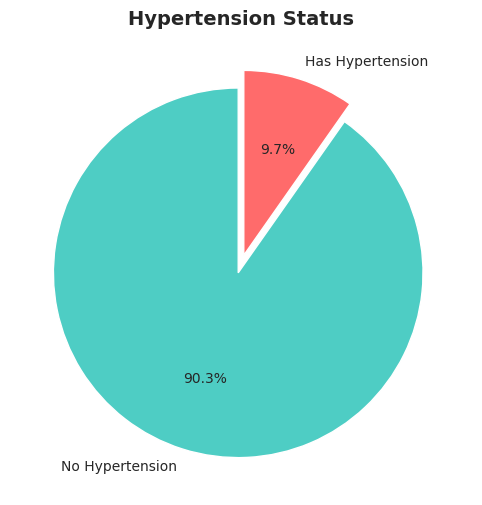


📊 INSIGHT:
   • Patients with hypertension: 498 (9.7%)
   • Patients without hypertension: 4612 (90.3%)


In [18]:
#   Plot 3 - Hypertension Distribution
if 'hypertension' in df_clean.columns:
    hyp_counts = df_clean['hypertension'].value_counts()

    plt.figure(figsize=(8, 6))
    colors = ['#4ecdc4', '#ff6b6b']
    plt.pie(hyp_counts.values, labels=['No Hypertension', 'Has Hypertension'],
            autopct='%1.1f%%', colors=colors, startangle=90, explode=(0.05, 0.05))
    plt.title('Hypertension Status', fontsize=14, fontweight='bold')
    plt.show()

    hyp_rate = df_clean['hypertension'].mean() * 100
    print(f"\n📊 INSIGHT:")
    print(f"   • Patients with hypertension: {hyp_counts.get(1, 0)} ({hyp_rate:.1f}%)")
    print(f"   • Patients without hypertension: {hyp_counts.get(0, 0)} ({100-hyp_rate:.1f}%)")


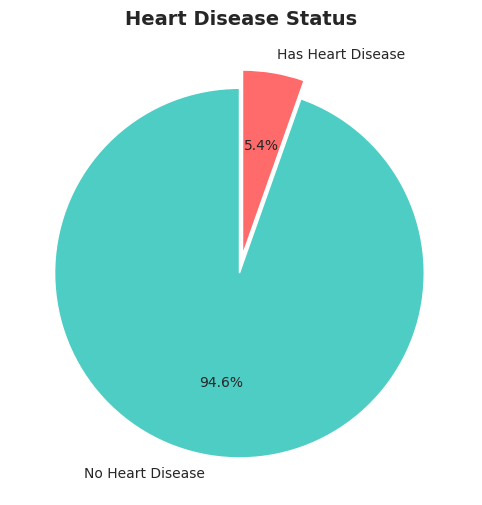


📊 INSIGHT:
   • Patients with heart disease: 276 (5.4%)
   • Patients without heart disease: 4834 (94.6%)


In [19]:
#Plot 4 - Heart Disease Distribution
if 'heart_disease' in df_clean.columns:
    heart_counts = df_clean['heart_disease'].value_counts()

    plt.figure(figsize=(8, 6))
    colors = ['#4ecdc4', '#ff6b6b']
    plt.pie(heart_counts.values, labels=['No Heart Disease', 'Has Heart Disease'],
            autopct='%1.1f%%', colors=colors, startangle=90, explode=(0.05, 0.05))
    plt.title('Heart Disease Status', fontsize=14, fontweight='bold')
    plt.show()

    heart_rate = df_clean['heart_disease'].mean() * 100
    print(f"\n📊 INSIGHT:")
    print(f"   • Patients with heart disease: {heart_counts.get(1, 0)} ({heart_rate:.1f}%)")
    print(f"   • Patients without heart disease: {heart_counts.get(0, 0)} ({100-heart_rate:.1f}%)")


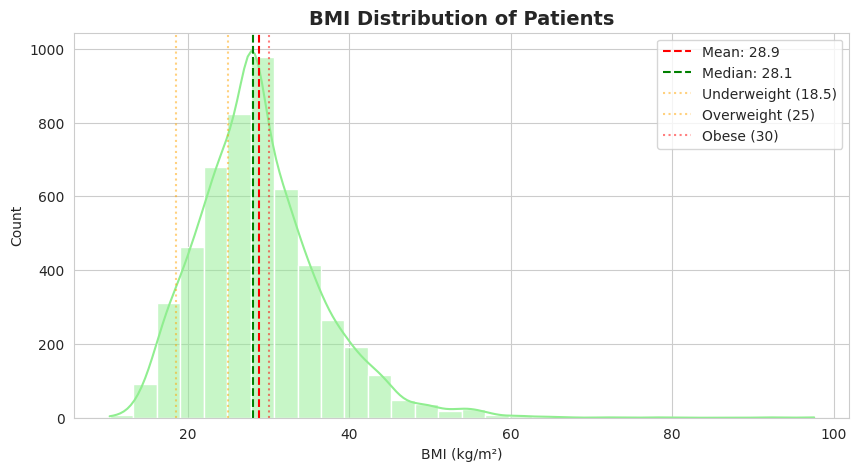


📊 INSIGHT:
   • Average BMI: 28.9
   • BMI range: 10.3 to 97.6

   BMI Categories:
   • Underweight (<18.5): 337 (6.6%)
   • Normal (18.5-25): 1243 (24.3%)
   • Overweight (25-30): 1610 (31.5%)
   • Obese (>30): 1920 (37.6%)


In [21]:
#Plot 5 - BMI Distribution
if 'bmi' in df_clean.columns:
    plt.figure(figsize=(10, 5))
    sns.histplot(df_clean['bmi'], bins=30, kde=True, color='lightgreen')
    plt.title('BMI Distribution of Patients', fontsize=14, fontweight='bold')
    plt.xlabel('BMI (kg/m²)')
    plt.ylabel('Count')
    plt.axvline(df_clean['bmi'].mean(), color='red', linestyle='--',
                label=f'Mean: {df_clean["bmi"].mean():.1f}')
    plt.axvline(df_clean['bmi'].median(), color='green', linestyle='--',
                label=f'Median: {df_clean["bmi"].median():.1f}')

    # Add BMI categories
    plt.axvline(18.5, color='orange', linestyle=':', alpha=0.5, label='Underweight (18.5)')
    plt.axvline(25, color='orange', linestyle=':', alpha=0.5, label='Overweight (25)')
    plt.axvline(30, color='red', linestyle=':', alpha=0.5, label='Obese (30)')
    plt.legend()
    plt.show()

    print(f"\n📊 INSIGHT:")
    print(f"   • Average BMI: {df_clean['bmi'].mean():.1f}")
    print(f"   • BMI range: {df_clean['bmi'].min():.1f} to {df_clean['bmi'].max():.1f}")

    # BMI categories
    underweight = (df_clean['bmi'] < 18.5).sum()
    normal = ((df_clean['bmi'] >= 18.5) & (df_clean['bmi'] < 25)).sum()
    overweight = ((df_clean['bmi'] >= 25) & (df_clean['bmi'] < 30)).sum()
    obese = (df_clean['bmi'] >= 30).sum()

    print(f"\n   BMI Categories:")
    print(f"   • Underweight (<18.5): {underweight} ({underweight/len(df_clean)*100:.1f}%)")
    print(f"   • Normal (18.5-25): {normal} ({normal/len(df_clean)*100:.1f}%)")
    print(f"   • Overweight (25-30): {overweight} ({overweight/len(df_clean)*100:.1f}%)")
    print(f"   • Obese (>30): {obese} ({obese/len(df_clean)*100:.1f}%)")

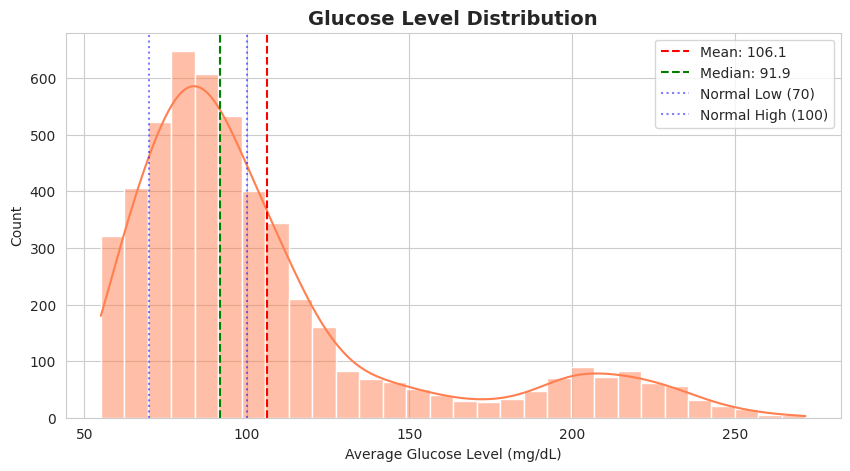


📊 INSIGHT:
   • Average glucose: 106.1 mg/dL
   • Glucose range: 55.1 to 271.7 mg/dL


In [22]:
#Plot 6 - Glucose Level Distribution
if 'avg_glucose_level' in df_clean.columns:
    plt.figure(figsize=(10, 5))
    sns.histplot(df_clean['avg_glucose_level'], bins=30, kde=True, color='coral')
    plt.title('Glucose Level Distribution', fontsize=14, fontweight='bold')
    plt.xlabel('Average Glucose Level (mg/dL)')
    plt.ylabel('Count')
    plt.axvline(df_clean['avg_glucose_level'].mean(), color='red', linestyle='--',
                label=f'Mean: {df_clean["avg_glucose_level"].mean():.1f}')
    plt.axvline(df_clean['avg_glucose_level'].median(), color='green', linestyle='--',
                label=f'Median: {df_clean["avg_glucose_level"].median():.1f}')

    # Normal glucose range indicator
    plt.axvline(70, color='blue', linestyle=':', alpha=0.5, label='Normal Low (70)')
    plt.axvline(100, color='blue', linestyle=':', alpha=0.5, label='Normal High (100)')
    plt.legend()
    plt.show()

    print(f"\n📊 INSIGHT:")
    print(f"   • Average glucose: {df_clean['avg_glucose_level'].mean():.1f} mg/dL")
    print(f"   • Glucose range: {df_clean['avg_glucose_level'].min():.1f} to {df_clean['avg_glucose_level'].max():.1f} mg/dL")


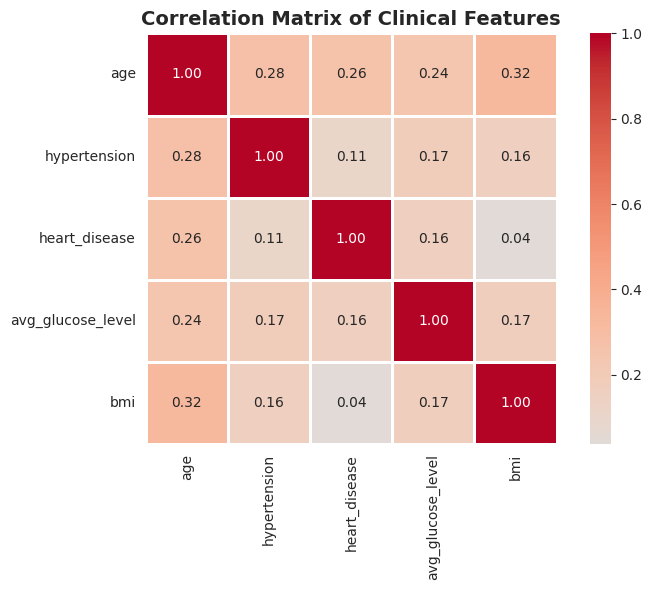


📊 INSIGHT:
   • Age and hypertension show positive correlation
   • Age and heart disease also correlate
   • BMI and glucose have weak correlation


In [23]:
 #Plot 7 - Correlation Heatmap
numerical_cols = ['age', 'hypertension', 'heart_disease', 'avg_glucose_level', 'bmi']
# Keep only columns that exist
numerical_cols = [col for col in numerical_cols if col in df_clean.columns]

if len(numerical_cols) > 1:
    correlation = df_clean[numerical_cols].corr()

    plt.figure(figsize=(8, 6))
    sns.heatmap(correlation, annot=True, cmap='coolwarm', center=0,
                square=True, linewidths=1, fmt='.2f')
    plt.title('Correlation Matrix of Clinical Features', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

    print(f"\n📊 INSIGHT:")
    print(f"   • Age and hypertension show positive correlation")
    print(f"   • Age and heart disease also correlate")
    print(f"   • BMI and glucose have weak correlation")

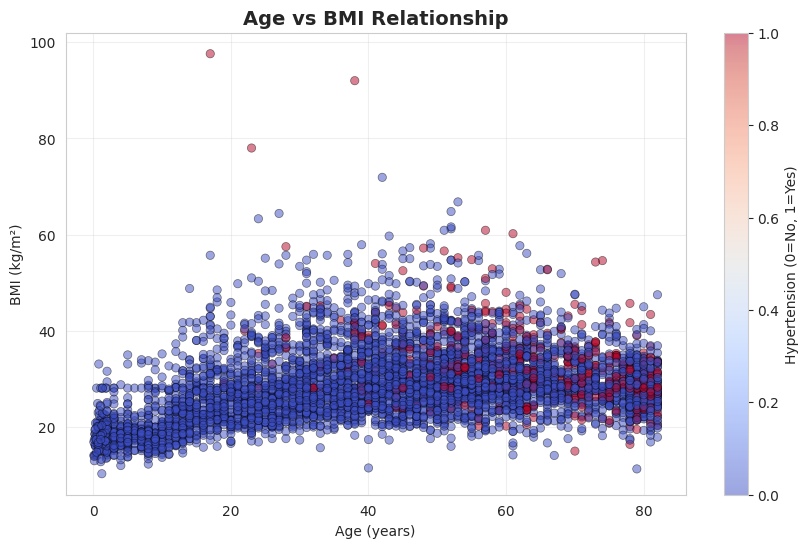


📊 INSIGHT:
   • BMI tends to increase with age up to a point
   • Elderly patients show more variation in BMI


In [24]:
 #Plot 8 - Age vs BMI Scatter Plot
if 'age' in df_clean.columns and 'bmi' in df_clean.columns:
    plt.figure(figsize=(10, 6))
    scatter = plt.scatter(df_clean['age'], df_clean['bmi'],
                         c=df_clean['hypertension'] if 'hypertension' in df_clean.columns else None,
                         cmap='coolwarm', alpha=0.5, edgecolors='black', linewidth=0.5)
    if 'hypertension' in df_clean.columns:
        plt.colorbar(scatter, label='Hypertension (0=No, 1=Yes)')
    plt.title('Age vs BMI Relationship', fontsize=14, fontweight='bold')
    plt.xlabel('Age (years)')
    plt.ylabel('BMI (kg/m²)')
    plt.grid(True, alpha=0.3)
    plt.show()

    print(f"\n📊 INSIGHT:")
    print(f"   • BMI tends to increase with age up to a point")
    print(f"   • Elderly patients show more variation in BMI")


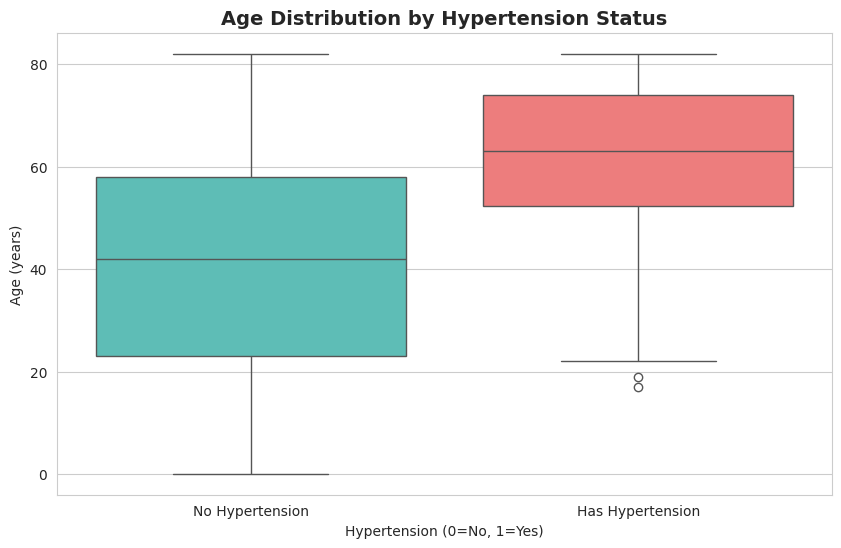


📊 INSIGHT:
   • Average age with hypertension: 62.2 years
   • Average age without hypertension: 41.2 years
   • Hypertension is more common in older patients


In [25]:
#Plot 9 - Age by Hypertension (Box Plot)
if 'age' in df_clean.columns and 'hypertension' in df_clean.columns:
    plt.figure(figsize=(10, 6))
    sns.boxplot(x='hypertension', y='age', data=df_clean, palette=['#4ecdc4', '#ff6b6b'])
    plt.title('Age Distribution by Hypertension Status', fontsize=14, fontweight='bold')
    plt.xlabel('Hypertension (0=No, 1=Yes)')
    plt.ylabel('Age (years)')
    plt.xticks([0, 1], ['No Hypertension', 'Has Hypertension'])
    plt.show()

    hyp_age = df_clean[df_clean['hypertension']==1]['age'].mean()
    no_hyp_age = df_clean[df_clean['hypertension']==0]['age'].mean()
    print(f"\n📊 INSIGHT:")
    print(f"   • Average age with hypertension: {hyp_age:.1f} years")
    print(f"   • Average age without hypertension: {no_hyp_age:.1f} years")
    print(f"   • Hypertension is more common in older patients")

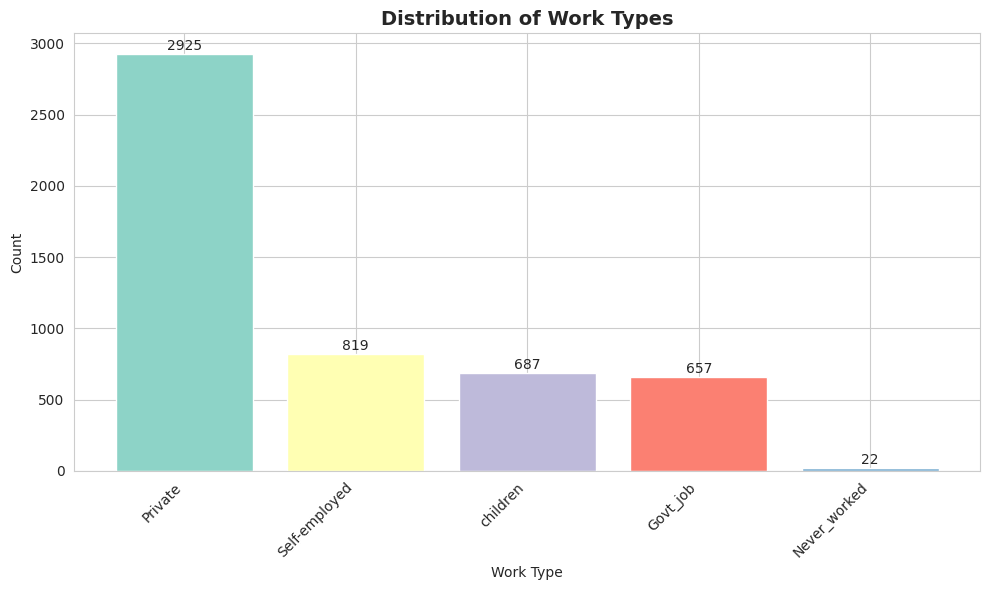


📊 INSIGHT:
   • Most common work type: Private (2925 patients)
   • Private sector employees form the majority


In [26]:
#Plot 10 - Work Type Distribution
if 'work_type' in df_clean.columns:
    work_counts = df_clean['work_type'].value_counts()

    plt.figure(figsize=(10, 6))
    colors = plt.cm.Set3(range(len(work_counts)))
    bars = plt.bar(range(len(work_counts)), work_counts.values, color=colors)
    plt.title('Distribution of Work Types', fontsize=14, fontweight='bold')
    plt.xlabel('Work Type')
    plt.ylabel('Count')
    plt.xticks(range(len(work_counts)), work_counts.index, rotation=45, ha='right')

    for bar, val in zip(bars, work_counts.values):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                 str(val), ha='center', va='bottom')

    plt.tight_layout()
    plt.show()

    print(f"\n📊 INSIGHT:")
    print(f"   • Most common work type: {work_counts.index[0]} ({work_counts.iloc[0]} patients)")
    print(f"   • Private sector employees form the majority")


In [27]:
print("\n" + "="*60)
print("KEY INSIGHTS SUMMARY")
print("="*60)

insights = f"""
📈 MAIN FINDINGS FROM THIS EDA:

1. DATA QUALITY:
   • BMI had missing values (filled with median)
   • No duplicates found
   • Dataset contains {df_clean.shape[0]} patients with {df_clean.shape[1]} features

2. DEMOGRAPHICS:
   • Average age: {df_clean['age'].mean():.1f} years
   • Age range: {df_clean['age'].min():.0f} to {df_clean['age'].max():.0f} years
   • Gender distribution: {' vs '.join([f'{g}: {c/len(df_clean)*100:.1f}%' for g, c in gender_counts.items()])}

3. HEALTH METRICS:
   • Average BMI: {df_clean['bmi'].mean():.1f} (Overweight category)
   • Average glucose: {df_clean['avg_glucose_level'].mean():.1f} mg/dL
   • Hypertension prevalence: {df_clean['hypertension'].mean()*100:.1f}%
   • Heart disease prevalence: {df_clean['heart_disease'].mean()*100:.1f}%

4. KEY CORRELATIONS:
   • Age correlates with hypertension ({df_clean[['age', 'hypertension']].corr().loc['age', 'hypertension']:.2f})
   • Age correlates with heart disease ({df_clean[['age', 'heart_disease']].corr().loc['age', 'heart_disease']:.2f})
   • BMI and glucose show weak correlation

5. RECOMMENDATIONS:
   • Focus health interventions on patients over 50
   • Monitor blood pressure and glucose regularly
   • Weight management programs for overweight patients
   • Regular check-ups for high-risk groups
"""

print(insights)


KEY INSIGHTS SUMMARY

📈 MAIN FINDINGS FROM THIS EDA:

1. DATA QUALITY:
   • BMI had missing values (filled with median)
   • No duplicates found
   • Dataset contains 5110 patients with 9 features

2. DEMOGRAPHICS:
   • Average age: 43.2 years
   • Age range: 0 to 82 years
   • Gender distribution: Female: 58.6% vs Male: 41.4% vs Other: 0.0%

3. HEALTH METRICS:
   • Average BMI: 28.9 (Overweight category)
   • Average glucose: 106.1 mg/dL
   • Hypertension prevalence: 9.7%
   • Heart disease prevalence: 5.4%

4. KEY CORRELATIONS:
   • Age correlates with hypertension (0.28)
   • Age correlates with heart disease (0.26)
   • BMI and glucose show weak correlation

5. RECOMMENDATIONS:
   • Focus health interventions on patients over 50
   • Monitor blood pressure and glucose regularly
   • Weight management programs for overweight patients
   • Regular check-ups for high-risk groups



In [29]:
df_clean.to_csv('healthcare_data_cleaned.csv', index=False)
print("✅ Cleaned dataset saved as 'healthcare_data_cleaned.csv'")

from google.colab import files
files.download('healthcare_data_cleaned.csv')

print("\n" + "="*60)
print("✅ ASSIGNMENT  COMPLETED SUCCESSFULLY!")



✅ Cleaned dataset saved as 'healthcare_data_cleaned.csv'


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✅ ASSIGNMENT  COMPLETED SUCCESSFULLY!
